In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [2]:
model_path = "../models/best_yolo8s_ball-detection.pt"
model = YOLO(model_path)

In [3]:
video_path = "../input_video/08fd33_4.mp4"

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
num_samples = 10  # ganti jadi 5 kalau mau lebih sedikit

# Ambil frame secara merata
frame_indices = np.linspace(0, total_frames - 1, num_samples, dtype=int)

frames = []

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

cap.release()

print(f"Berhasil ambil {len(frames)} frame")

Berhasil ambil 10 frame


In [4]:
results = model(frames, imgsz=1280, conf=0.25)


0: 736x1280 1 ball, 763.1ms
1: 736x1280 1 ball, 763.1ms
2: 736x1280 2 balls, 763.1ms
3: 736x1280 3 balls, 763.1ms
4: 736x1280 2 balls, 763.1ms
5: 736x1280 1 ball, 763.1ms
6: 736x1280 2 balls, 763.1ms
7: 736x1280 6 balls, 763.1ms
8: 736x1280 3 balls, 763.1ms
9: 736x1280 3 balls, 763.1ms
Speed: 17.8ms preprocess, 763.1ms inference, 6.5ms postprocess per image at shape (1, 3, 736, 1280)


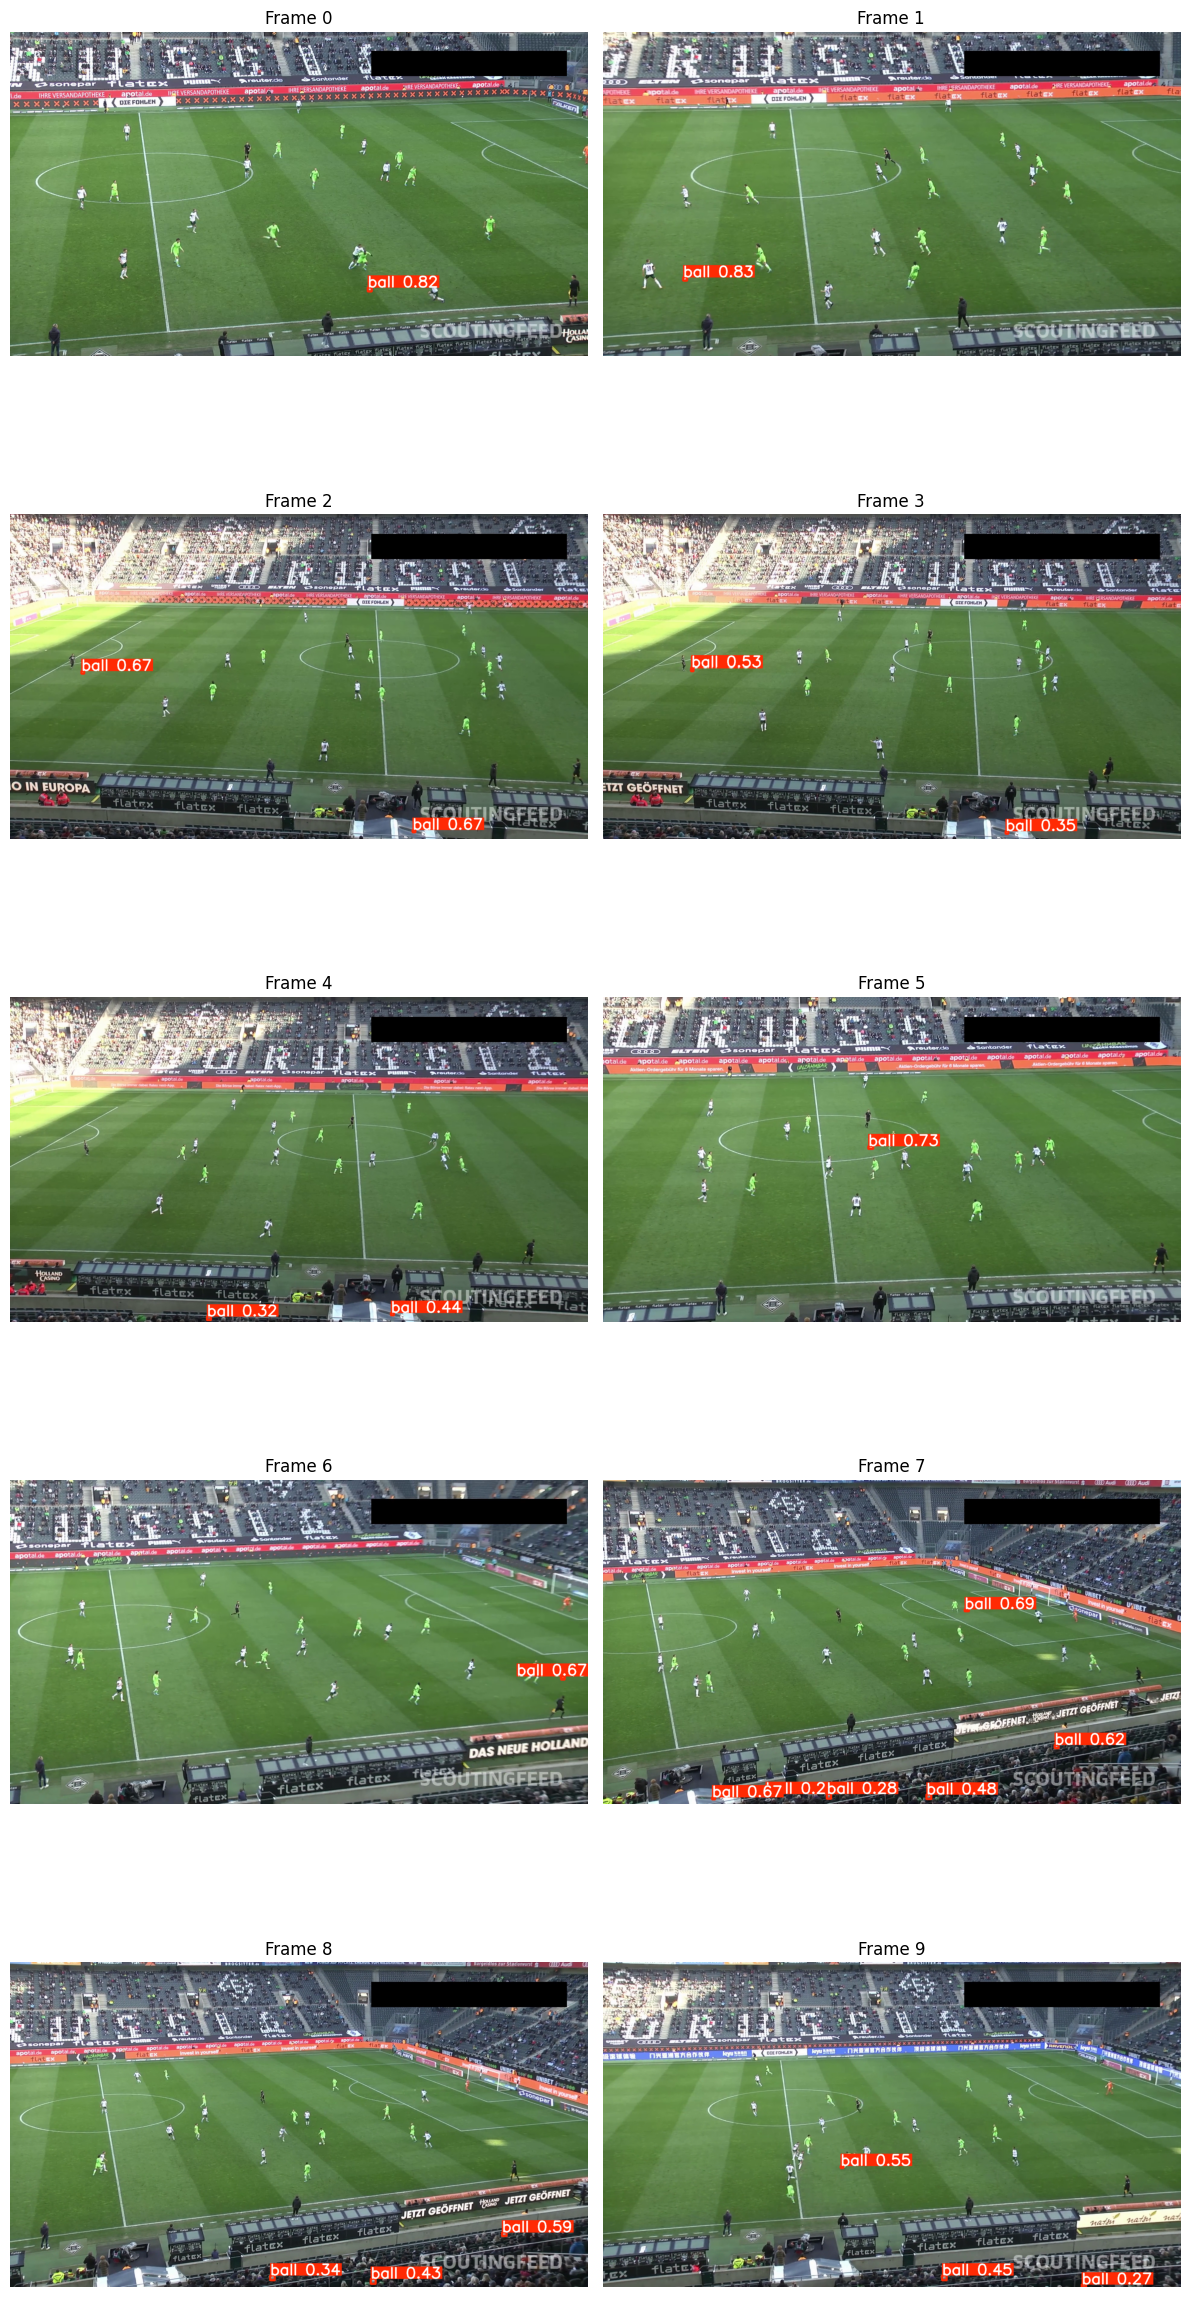

In [5]:
num_frames = len(results)

cols = 2 
rows = (num_frames + cols - 1) // cols

plt.figure(figsize=(12, rows * 5))  # tinggi otomatis ikut jumlah row

for i, result in enumerate(results):
    annotated = result.plot()
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(annotated)
    plt.title(f"Frame {i}", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
for i, result in enumerate(results):
    print(f"Frame {i}")
    for box in result.boxes:
        print("  Conf:", float(box.conf))
        print("  Class:", int(box.cls))
        print("  BBox:", box.xyxy.tolist())
    print("------")

Frame 0
  Conf: 0.8189113736152649
  Class: 0
  BBox: [[1188.0369873046875, 852.169921875, 1201.8251953125, 865.0667724609375]]
------
Frame 1
  Conf: 0.827424168586731
  Class: 0
  BBox: [[266.2897644042969, 818.1264038085938, 279.9544677734375, 829.6931762695312]]
------
Frame 2
  Conf: 0.6683850288391113
  Class: 0
  BBox: [[237.7683563232422, 521.9903564453125, 246.1699676513672, 530.2061157226562]]
  Conf: 0.6678966283798218
  Class: 0
  BBox: [[1337.3411865234375, 1049.9866943359375, 1346.376708984375, 1057.9140625]]
------
Frame 3
  Conf: 0.5317224860191345
  Class: 0
  BBox: [[293.0151062011719, 509.9975280761719, 300.32366943359375, 518.764404296875]]
  Conf: 0.3477506935596466
  Class: 0
  BBox: [[1337.9029541015625, 1053.3509521484375, 1346.5631103515625, 1062.006591796875]]
  Conf: 0.3053347170352936
  Class: 0
  BBox: [[292.9328918457031, 512.2459716796875, 300.1642761230469, 522.0016479492188]]
------
Frame 4
  Conf: 0.43779903650283813
  Class: 0
  BBox: [[1265.922729492